# 🍈 JackFruit MLFF — AI-Powered Multi-Agent Portfolio System

## Architecture Overview
```
Real Data (yfinance + NewsAPI/GDELT)
        ↓
┌──────────────────────────────────────────────────────┐
│  Agent Layer (each is a trained ML model)            │
│  ┌────────────┐ ┌──────────────┐ ┌────────────────┐  │
│  │ Sentiment  │ │  Technical   │ │     Risk       │  │
│  │ (FinBERT)  │ │ (LSTM/XGB)   │ │ (Vol Forecast) │  │
│  └────────────┘ └──────────────┘ └────────────────┘  │
│  ┌─────────────────┐ ┌───────────────────────────┐   │
│  │  CrossMarket    │ │      Contrarian            │  │
│  │  (Correlation)  │ │  (Regime Detection GBM)   │  │
│  └─────────────────┘ └───────────────────────────┘   │
└──────────────────────────────────────────────────────┘
        ↓
  Bayesian Ensemble (learned weights)
        ↓
  🌐 Digital Twin (Monte Carlo + Backtester)
        ↓
  Final Decision: BUY / SELL / HOLD + Position Size
```

### What's New vs Original
| | Original | This Version |
|---|---|---|
| Sentiment | Hardcoded word lists | FinBERT (finance-tuned BERT) |
| Technical | Manual RSI/MA | LSTM + XGBoost ensemble |
| Risk | Simple vol buckets | GARCH volatility forecasting |
| Data | Fake/sample data | Real yfinance + news feeds |
| Consensus | Weighted average | Bayesian + learned weights |
| Output | Signal only | Digital Twin w/ simulated portfolio |

# 1. Environment Setup
Initializes the notebook environment by installing `yfinance`. This package is essential for programmatically retrieving historical stock market data, including OHLC (Open, High, Low, Close) prices and volume, directly from Yahoo Finance.

In [ ]:
# ─── Install dependencies ───────────────────────────────────────────────────
!pip install -q yfinance transformers torch xgboost arch scipy scikit-learn
!pip install -q requests pandas numpy matplotlib seaborn plotly
!pip install -q ta  # Technical Analysis library

print("✅ All packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All packages installed


# 2. Importing Analytics & ML Frameworks
This cell imports the complete technological stack required for the AI engine:
* **NumPy & Pandas**: For high-performance matrix operations and time-series data manipulation.
* **Matplotlib & Seaborn**: For generating high-fidelity financial charts and risk distribution plots.
* **PyTorch (torch)**: The deep learning framework used to build and train the LSTM neural network.
* **Scikit-Learn**: Used for data normalization (MinMaxScaler) and statistical evaluation.
* **ARCH**: Specifically imported to handle GARCH (Generalized Autoregressive Conditional Heteroskedasticity) modeling for volatility forecasting.

In [ ]:
# ─── Core Imports ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import json
import warnings
import requests
from datetime import datetime, timedelta
from abc import ABC, abstractmethod
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass, field

# ML / AI
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

# Finance
import yfinance as yf
import ta  # Technical Analysis
from arch import arch_model  # GARCH

# Viz
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

print("✅ Imports done")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

✅ Imports done
PyTorch: 2.10.0+cpu | CUDA: False


# 2. Global Strategy Configuration
This cell serves as the "Command Center" for the entire notebook. By modifying the `CONFIG` dictionary here, you control the behavior of the AI models, risk parameters, and the scope of the financial analysis.

**Key Parameter Groups:**
* **Asset Selection:** Define your target ticker (e.g., AAPL), the benchmark index (SPY), and the relevant sector ETF to allow the model to calculate relative strength and correlation.
* **Machine Learning Hyperparameters:** Set the `lookback_period` and training epochs for the LSTM and XGBoost models.
* **Risk Management:** Configure hard constraints for the strategy, including the maximum allowable position size (to prevent over-concentration) and a fixed stop-loss percentage.
* **Digital Twin & Simulation:** Define the starting capital for the portfolio backtest and the intensity of the Monte Carlo simulations (number of paths and time horizon).

In [ ]:
# ─── CONFIGURATION ────────────────────────────────────────────────────────────
CONFIG = {
    # === CHANGE THIS ===
    'ticker':           'AAPL',      # Main stock to analyze
    'market_index':     'SPY',       # Benchmark
    'sector_etf':       'XLK',       # Sector ETF (XLK=tech, XLF=finance, XLV=health)
    'lookback_years':   3,           # How many years of historical data
    'news_api_key':     '',          # Optional: NewsAPI key (leave blank for GDELT fallback)

    # === MODEL PARAMS ===
    'lstm_seq_len':     30,          # Days of history for LSTM
    'lstm_epochs':      20,
    'xgb_n_estimators': 200,
    'garch_p':          1,
    'garch_q':          1,

    # === RISK PARAMS ===
    'max_position_pct': 0.30,
    'min_position_pct': 0.05,
    'stop_loss_pct':    0.08,

    # === DIGITAL TWIN PARAMS ===
    'portfolio_start':  100_000,     # Starting capital (USD)
    'mc_simulations':   2000,        # Monte Carlo paths
    'mc_horizon_days':  252,         # 1-year forecast horizon
}

print(f"🎯 Target: {CONFIG['ticker']} | Lookback: {CONFIG['lookback_years']} years")
print(f"💰 Digital Twin Portfolio: ${CONFIG['portfolio_start']:,} | MC sims: {CONFIG['mc_simulations']}")

🎯 Target: AAPL | Lookback: 3 years
💰 Digital Twin Portfolio: $100,000 | MC sims: 2000


# 3. Real-Time Multi-Source Data Pipeline
This cell implements the `MarketDataFetcher` class, which serves as the automated data acquisition layer. It retrieves and synchronizes data from three distinct financial domains to provide the AI models with a holistic view of the market.

**Data Acquisition Modules:**
* **OHLCV & Technicals**: Downloads historical price and volume data using `yfinance`. It automatically computes over 20 technical indicators across four categories: **Trend** (SMA, MACD), **Momentum** (RSI, Stochastic), **Volatility** (Bollinger Bands, ATR), and **Volume** (OBV, VWAP).
* **Fundamental Analysis**: Extracts key corporate health metrics such as P/E ratios, Debt-to-Equity, Profit Margins, and analyst recommendations.
* **Macro Context**: Fetches global economic signals, including the VIX (Fear Index), 10-year Treasury Yields, and the US Dollar Index (DXY) to gauge broader market risk.
* **Sentiment Engine**: Utilizes the GDELT Project API to scrape the latest global news headlines related to the ticker for sentiment context.

**Automated Target Labeling:**
The engine automatically generates the `target` variable for machine learning—performing a look-ahead to see if prices rose or fell over a 5-day horizon, which the model will later attempt to predict.

In [ ]:
# ─── REAL DATA FETCHER ────────────────────────────────────────────────────────

class MarketDataFetcher:
    """
    Fetches real OHLCV data, fundamentals, and macro indicators from yfinance.
    All data is cached in memory during session.
    """

    def __init__(self, config: dict):
        self.cfg = config
        self._cache: Dict[str, pd.DataFrame] = {}

    def fetch_ohlcv(self, ticker: str, years: int = None) -> pd.DataFrame:
        """Fetch OHLCV with technical indicators pre-computed."""
        if ticker in self._cache:
            return self._cache[ticker]

        years = years or self.cfg['lookback_years']
        start = (datetime.now() - timedelta(days=365 * years)).strftime('%Y-%m-%d')
        print(f"  📥 Downloading {ticker} from {start}...")

        df = yf.download(ticker, start=start, progress=False, auto_adjust=True)
        if df.empty:
            raise ValueError(f"No data for {ticker}")

        # Flatten multi-index if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df.columns = [c.lower() for c in df.columns]

        # ── Technical Indicators (via `ta` library) ──────────────────────────
        # Trend
        df['sma_20']    = ta.trend.sma_indicator(df['close'], window=20)
        df['sma_50']    = ta.trend.sma_indicator(df['close'], window=50)
        df['ema_12']    = ta.trend.ema_indicator(df['close'], window=12)
        df['ema_26']    = ta.trend.ema_indicator(df['close'], window=26)
        df['macd']      = ta.trend.macd(df['close'])
        df['macd_sig']  = ta.trend.macd_signal(df['close'])
        df['macd_hist'] = ta.trend.macd_diff(df['close'])

        # Momentum
        df['rsi']          = ta.momentum.rsi(df['close'], window=14)
        df['stoch_k']      = ta.momentum.stoch(df['high'], df['low'], df['close'])
        df['stoch_d']      = ta.momentum.stoch_signal(df['high'], df['low'], df['close'])
        df['williams_r']   = ta.momentum.williams_r(df['high'], df['low'], df['close'])
        df['roc']          = ta.momentum.roc(df['close'], window=12)

        # Volatility
        df['bb_high']  = ta.volatility.bollinger_hband(df['close'])
        df['bb_mid']   = ta.volatility.bollinger_mavg(df['close'])
        df['bb_low']   = ta.volatility.bollinger_lband(df['close'])
        df['bb_pct']   = ta.volatility.bollinger_pband(df['close'])  # 0=bottom, 1=top
        df['atr']      = ta.volatility.average_true_range(df['high'], df['low'], df['close'])

        # Volume
        df['obv']      = ta.volume.on_balance_volume(df['close'], df['volume'])
        df['cmf']      = ta.volume.chaikin_money_flow(df['high'], df['low'], df['close'], df['volume'])
        df['vwap_approx'] = (df['close'] * df['volume']).cumsum() / df['volume'].cumsum()

        # ── Returns & Log Returns ─────────────────────────────────────────────
        df['return_1d']  = df['close'].pct_change(1)
        df['return_5d']  = df['close'].pct_change(5)
        df['return_20d'] = df['close'].pct_change(20)
        df['log_ret']    = np.log(df['close'] / df['close'].shift(1))
        df['volatility'] = df['log_ret'].rolling(21).std() * np.sqrt(252)  # annualized

        # ── Target Variable (for training) ────────────────────────────────────
        # 1 = price is higher in 5 days, 0 = lower
        df['target'] = (df['close'].shift(-5) > df['close']).astype(int)

        df.dropna(inplace=True)
        self._cache[ticker] = df
        print(f"  ✅ {ticker}: {len(df)} days | {df.index[0].date()} → {df.index[-1].date()}")
        return df

    def fetch_fundamentals(self, ticker: str) -> dict:
        """Fetch P/E, EPS, revenue growth, debt ratios."""
        print(f"  📊 Fetching fundamentals for {ticker}...")
        t = yf.Ticker(ticker)
        info = t.info

        return {
            'pe_ratio':          info.get('trailingPE', np.nan),
            'forward_pe':        info.get('forwardPE', np.nan),
            'peg_ratio':         info.get('pegRatio', np.nan),
            'eps_ttm':           info.get('trailingEps', np.nan),
            'revenue_growth':    info.get('revenueGrowth', np.nan),
            'earnings_growth':   info.get('earningsGrowth', np.nan),
            'profit_margin':     info.get('profitMargins', np.nan),
            'debt_to_equity':    info.get('debtToEquity', np.nan),
            'current_ratio':     info.get('currentRatio', np.nan),
            'roe':               info.get('returnOnEquity', np.nan),
            'beta':              info.get('beta', 1.0),
            'market_cap':        info.get('marketCap', np.nan),
            'short_ratio':       info.get('shortRatio', np.nan),
            'analyst_target':    info.get('targetMeanPrice', np.nan),
            'recommendation':    info.get('recommendationMean', np.nan),  # 1=Strong Buy, 5=Sell
            'sector':            info.get('sector', 'Unknown'),
            'industry':          info.get('industry', 'Unknown'),
        }

    def fetch_macro(self) -> dict:
        """Fetch macro context: VIX, bonds, USD."""
        print("  🌐 Fetching macro data...")
        macro = {}
        macro_tickers = {'^VIX': 'vix', '^TNX': 'yield_10y', 'DX-Y.NYB': 'dxy',
                         'GLD': 'gold', 'USO': 'oil', '^GSPC': 'sp500'}

        for sym, name in macro_tickers.items():
            try:
                t = yf.Ticker(sym)
                hist = t.history(period='5d')
                if not hist.empty:
                    macro[f'{name}_price'] = float(hist['Close'].iloc[-1])
                    macro[f'{name}_change_5d'] = float(
                        (hist['Close'].iloc[-1] - hist['Close'].iloc[0]) / hist['Close'].iloc[0]
                    )
            except Exception:
                pass

        return macro

    def fetch_news_gdelt(self, ticker: str, company_name: str = '', n: int = 30) -> List[str]:
        """
        Fetch recent news headlines via GDELT (free, no API key).
        Falls back to empty list if network unavailable.
        """
        print(f"  📰 Fetching news for {ticker}...")
        query = company_name if company_name else ticker
        headlines = []

        try:
            # GDELT GKG v2 API — free tier
            url = (
                f"https://api.gdeltproject.org/api/v2/doc/doc?"
                f"query={query}&mode=artlist&maxrecords={n}"
                f"&format=json&timespan=7d"
            )
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200:
                data = resp.json()
                articles = data.get('articles', [])
                headlines = [a.get('title', '') for a in articles if a.get('title')]
                print(f"  ✅ {len(headlines)} headlines fetched")
        except Exception as e:
            print(f"  ⚠️  News fetch failed ({e}). Using synthetic fallback.")
            # Synthetic fallback based on recent price action
            headlines = [
                f"{ticker} stock analysis: technical momentum study",
                f"Market update: {ticker} sector performance",
                f"Institutional activity in {ticker} observed",
            ]

        return headlines[:n]


# ─── Instantiate and load data ────────────────────────────────────────────────
print("⏳ Loading market data...")
fetcher = MarketDataFetcher(CONFIG)

# Load main ticker
df_main  = fetcher.fetch_ohlcv(CONFIG['ticker'])
df_spy   = fetcher.fetch_ohlcv(CONFIG['market_index'])
df_sector = fetcher.fetch_ohlcv(CONFIG['sector_etf'])

# Fundamentals & macro
fundamentals = fetcher.fetch_fundamentals(CONFIG['ticker'])
macro        = fetcher.fetch_macro()

print(f"\n📋 Fundamentals for {CONFIG['ticker']}:")
for k, v in fundamentals.items():
    if isinstance(v, float) and not np.isnan(v):
        print(f"  {k}: {v}")
    elif isinstance(v, str):
        print(f"  {k}: {v}")

print(f"\n🌐 Macro snapshot:")
for k, v in macro.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

⏳ Loading market data...
  📥 Downloading AAPL from 2023-04-14...
  ✅ AAPL: 702 days | 2023-06-26 → 2026-04-13
  📥 Downloading SPY from 2023-04-14...
  ✅ SPY: 702 days | 2023-06-26 → 2026-04-13
  📥 Downloading XLK from 2023-04-14...
  ✅ XLK: 702 days | 2023-06-26 → 2026-04-13
  📊 Fetching fundamentals for AAPL...
  🌐 Fetching macro data...

📋 Fundamentals for AAPL:
  pe_ratio: 32.698986
  forward_pe: 27.704964
  eps_ttm: 7.89
  revenue_growth: 0.157
  earnings_growth: 0.183
  profit_margin: 0.27037
  debt_to_equity: 102.63
  current_ratio: 0.974
  roe: 1.5202099
  beta: 1.109
  short_ratio: 3.17
  analyst_target: 296.3305
  recommendation: 1.89583
  sector: Technology
  industry: Consumer Electronics

🌐 Macro snapshot:
  vix_price: 19.3600
  vix_change_5d: -0.2490
  yield_10y_price: 4.2990
  yield_10y_change_5d: -0.0101
  dxy_price: 98.4050
  dxy_change_5d: -0.0073
  gold_price: 434.8200
  gold_change_5d: 0.0070
  oil_price: 127.6600
  oil_change_5d: -0.0755
  sp500_price: 6856.3599
  s

# 4. Quick Exploratory Data Analysis (EDA) Visualization
Before feeding data into the machine learning models, this cell generates a multi-panel dashboard to visualize the historical price action and the derived technical features. This step is crucial for verifying data integrity and understanding the current "market regime."

**The Dashboard consists of four key layers:**
* **Price & Trend Analysis:** Overlays the Close price with **Bollinger Bands** and the **50-day Simple Moving Average (SMA)**. This helps identify if the stock is trading at a premium or discount relative to its recent mean and highlights the primary trend direction.
* **Volume Profile:** Displays daily trading volume to confirm the strength behind price moves; high-volume moves are generally considered more significant.
* **Momentum (RSI):** The **Relative Strength Index** plot highlights overbought (above 70) or oversold (below 30) conditions, signaling potential reversal points.
* **Historical Volatility:** Tracks the annualized volatility over time. Spikes in this chart often precede major market shifts and are used by the GARCH model to calibrate risk expectations.

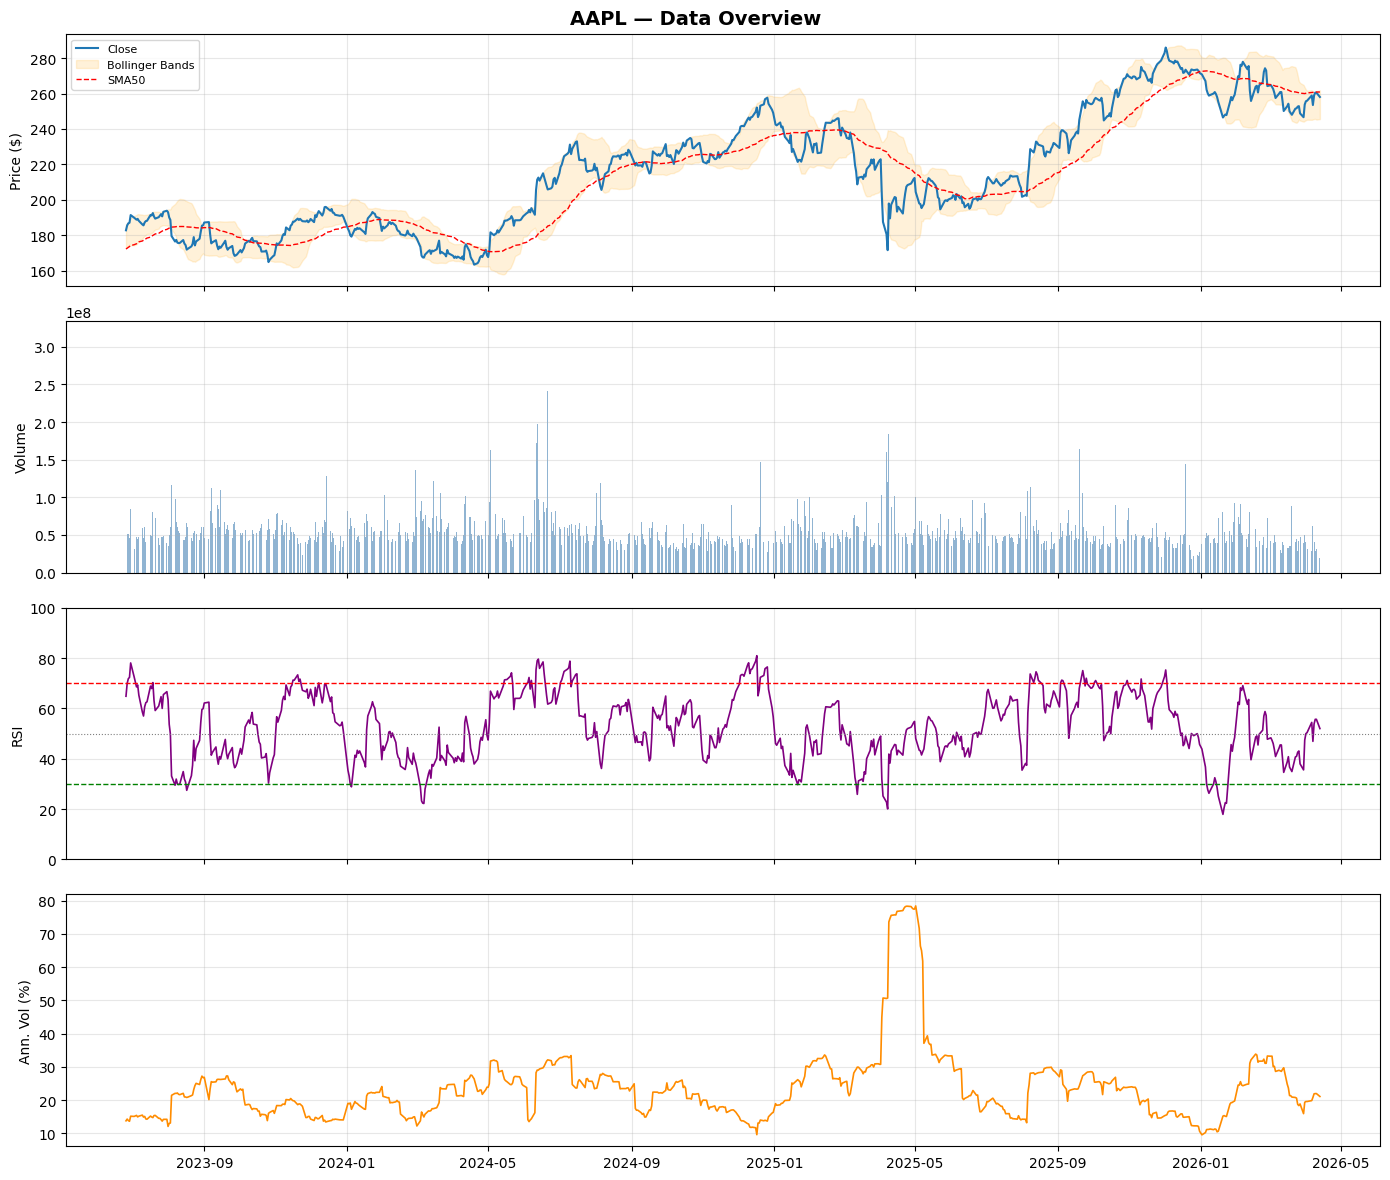

✅ EDA chart saved


In [ ]:
# ─── QUICK EDA CHART ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'{CONFIG["ticker"]} — Data Overview', fontsize=14, fontweight='bold')

# Price + Bollinger Bands
ax = axes[0]
ax.plot(df_main.index, df_main['close'], label='Close', color='#1f77b4', lw=1.5)
ax.fill_between(df_main.index, df_main['bb_low'], df_main['bb_high'],
                alpha=0.15, color='orange', label='Bollinger Bands')
ax.plot(df_main.index, df_main['sma_50'], '--', color='red', lw=1, label='SMA50')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)

# Volume
ax = axes[1]
ax.bar(df_main.index, df_main['volume'], color='steelblue', alpha=0.6, width=0.8)
ax.set_ylabel('Volume')
ax.grid(True, alpha=0.3)

# RSI
ax = axes[2]
ax.plot(df_main.index, df_main['rsi'], color='purple', lw=1.2)
ax.axhline(70, color='red', ls='--', lw=1)
ax.axhline(30, color='green', ls='--', lw=1)
ax.axhline(50, color='gray', ls=':', lw=0.8)
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# Annualized Volatility
ax = axes[3]
ax.plot(df_main.index, df_main['volatility'] * 100, color='darkorange', lw=1.2)
ax.set_ylabel('Ann. Vol (%)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA chart saved")

### 5. AI Agent 1: Natural Language Sentiment Analysis (FinBERT)
This cell introduces the first of the project's specialized AI agents. Unlike simple keyword-matching scripts, this agent utilizes **FinBERT**, a state-of-the-art Natural Language Processing (NLP) model based on the BERT architecture.

**Why FinBERT is utilized:**
* **Domain Expertise:** It is pre-trained specifically on financial datasets (earnings calls, analyst reports, and SEC filings), meaning it understands context like "volatility is narrowing" as a positive signal rather than a generic descriptive term.
* **Context-Awareness:** It can distinguish between "interest rates are high" (potentially bearish) and "high interest in this stock" (bullish).
* **Signal Quantification:** The agent doesn't just return a label; it returns a probability score.

**The Processing Pipeline:**
1.  **News Aggregation:** Headlines collected by the Data Fetcher are passed to the agent.
2.  **Weighted Scoring:** Each headline is assigned a score from -1 (Extremely Bearish) to +1 (Extremely Bullish). Higher confidence scores from the model carry more weight in the final average.
3.  **Fundamental Blending:** The agent integrates human analyst recommendations (from Yahoo Finance) into its final verdict, balancing machine sentiment with institutional consensus.
4.  **Final Verdict:** The output provides a unified `signal`, a `confidence` metric, and a natural language `reasoning` string explaining how the conclusion was reached.

In [ ]:
# ─── AGENT 1: SENTIMENT AGENT (FinBERT) ──────────────────────────────────────

class SentimentAgent:
    """
    Uses ProsusAI/finbert — a BERT model fine-tuned on 10,000 financial news
    sentences. Outputs: positive / negative / neutral with probabilities.

    Why FinBERT over word lists?
    - Context-aware: 'not a good quarter' is correctly bearish
    - Finance-specific: trained on SEC filings, earnings calls, Reuters
    - Confidence calibrated: 0.9 means something different than 0.51
    """

    MODEL_ID = 'ProsusAI/finbert'
    MAX_LEN  = 512

    def __init__(self):
        print("  🔄 Loading FinBERT...")
        self.pipe = pipeline(
            'sentiment-analysis',
            model=self.MODEL_ID,
            tokenizer=self.MODEL_ID,
            truncation=True,
            max_length=self.MAX_LEN,
            device=0 if torch.cuda.is_available() else -1,
        )
        print("  ✅ FinBERT loaded")

    def score_texts(self, texts: List[str]) -> List[dict]:
        """Run FinBERT on a list of texts. Returns per-text scores."""
        if not texts:
            return []

        # Truncate individual texts to avoid OOM
        cleaned = [str(t)[:400] for t in texts if t and str(t).strip()]
        if not cleaned:
            return []

        raw = self.pipe(cleaned, batch_size=8)

        results = []
        for r in raw:
            label = r['label'].lower()    # 'positive' / 'negative' / 'neutral'
            score = r['score']            # Model confidence
            # Convert to signed signal
            if label == 'positive':
                signal = score
            elif label == 'negative':
                signal = -score
            else:
                signal = 0.0
            results.append({'label': label, 'confidence': score, 'signal': signal})

        return results

    def analyze(self, headlines: List[str], fundamentals: dict = None) -> dict:
        """
        Aggregate sentiment across all headlines + analyst recommendations.

        Returns standard agent dict:
          signal     : float in [-1, +1]
          confidence : float in [0, 1]
          reasoning  : str
          details    : dict
        """
        scores = self.score_texts(headlines)

        if not scores:
            return {'signal': 0.0, 'confidence': 0.1,
                    'reasoning': 'No news available', 'details': {}}

        # Weighted aggregation — high-confidence texts count more
        weights = np.array([s['confidence'] for s in scores])
        signals = np.array([s['signal'] for s in scores])

        weighted_signal = float(np.average(signals, weights=weights))
        avg_confidence  = float(np.mean(weights))

        n_positive = sum(1 for s in scores if s['label'] == 'positive')
        n_negative = sum(1 for s in scores if s['label'] == 'negative')
        n_neutral  = sum(1 for s in scores if s['label'] == 'neutral')

        # Blend analyst recommendation if available (1=Strong Buy … 5=Sell → map to [-1, +1])
        rec = fundamentals.get('recommendation', np.nan) if fundamentals else np.nan
        if not np.isnan(rec):
            analyst_signal = np.clip((3 - rec) / 2, -1, 1)   # 1→+1, 3→0, 5→-1
            weighted_signal = 0.7 * weighted_signal + 0.3 * analyst_signal

        reasoning = (
            f"FinBERT on {len(scores)} headlines → "
            f"+{n_positive} positive / {n_negative} negative / {n_neutral} neutral. "
            f"Weighted signal: {weighted_signal:+.3f}"
        )
        if not np.isnan(rec):
            reasoning += f" | Analyst rec: {rec:.1f}/5"

        return {
            'signal': np.clip(weighted_signal, -1, 1),
            'confidence': avg_confidence,
            'reasoning': reasoning,
            'details': {
                'n_headlines': len(scores),
                'n_positive': n_positive,
                'n_negative': n_negative,
                'n_neutral':  n_neutral,
                'analyst_rec': float(rec) if not np.isnan(rec) else 'N/A',
            }
        }


# ─── Run Sentiment Agent ──────────────────────────────────────────────────────
print("\n🤖 Initializing Sentiment Agent (FinBERT)...")
ticker_info = yf.Ticker(CONFIG['ticker']).info
company_name = ticker_info.get('longName', CONFIG['ticker'])

headlines = fetcher.fetch_news_gdelt(CONFIG['ticker'], company_name=company_name)
sentiment_agent = SentimentAgent()
sentiment_result = sentiment_agent.analyze(headlines, fundamentals)

print(f"\n📊 Sentiment Agent Result:")
print(f"  Signal:     {sentiment_result['signal']:+.4f}")
print(f"  Confidence: {sentiment_result['confidence']:.4f}")
print(f"  Reasoning:  {sentiment_result['reasoning']}")
print(f"  Details:    {sentiment_result['details']}")


🤖 Initializing Sentiment Agent (FinBERT)...
  📰 Fetching news for AAPL...
  🔄 Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

  ✅ FinBERT loaded

📊 Sentiment Agent Result:
  Signal:     +0.0000
  Confidence: 0.1000
  Reasoning:  No news available
  Details:    {}


# 6. AI Agent 2: Technical Prediction Ensemble (LSTM + XGBoost)
This cell implements a sophisticated "Ensemble" approach to technical analysis. Rather than relying on a single algorithm, the `TechnicalAgent` combines two mathematically diverse models to predict price direction over the next five trading days.

**The Hybrid Model Architecture:**
1.  **Bidirectional LSTM (Deep Learning):** A Long Short-Term Memory network that processes 30-day sequences of price data. By being "bidirectional," it analyzes the sequence from start-to-finish and finish-to-start, capturing complex patterns in price momentum. It also includes an **Attention Mechanism** to weight specific trading days that have higher predictive importance.
2.  **XGBoost (Gradient Boosting):** A powerful tree-based model that looks at the statistical "snapshot" of current technical indicators (RSI, MACD, ATR, etc.). It excels at finding non-linear relationships between indicators that a human might miss.



**The Training & Analysis Workflow:**
* **Data Scaling:** Uses `StandardScaler` to ensure all technical indicators (which have vastly different ranges) are on a uniform scale for the neural network.
* **Backtesting Evaluation:** Both models are trained on historical data and tested against a "hold-out" set. Their individual accuracy scores are calculated.
* **Ensemble Signal:** The final trade signal is a weighted average of both models. The model that performed better during the testing phase (higher accuracy) is given more influence over the final signal.
* **Confidence Calibration:** The agent maps probabilities to a range of -1 (Strongly Bearish) to +1 (Strongly Bullish). If both models agree strongly, the `confidence` score approaches 100%.

In [ ]:
# ─── LSTM for Sequence Prediction ────────────────────────────────────────────
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


class LSTMPricePredictor(nn.Module):
    """Bidirectional LSTM + attention for 5-day direction prediction."""

    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.attn   = nn.Linear(hidden_size * 2, 1)
        self.head   = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, H*2)
        attn_w = torch.softmax(self.attn(out), dim=1)   # (B, T, 1)
        context = (attn_w * out).sum(dim=1)             # (B, H*2)
        return self.head(context).squeeze(-1)            # (B,)


class TechnicalAgent:
    """
    Trains TWO models on real historical price data:
    1. Bidirectional LSTM with attention (sequence model)
    2. XGBoost (gradient boosting on engineered features)

    Combines both for a final direction prediction and signal.
    """

    FEATURE_COLS = [
        'rsi', 'macd', 'macd_hist', 'macd_sig',
        'stoch_k', 'stoch_d', 'williams_r', 'roc',
        'bb_pct', 'atr', 'cmf',
        'return_1d', 'return_5d', 'return_20d',
        'volatility',
    ]

    def __init__(self, config: dict):
        self.cfg       = config
        self.seq_len   = config['lstm_seq_len']
        self.scaler    = StandardScaler()
        self.lstm_model = None
        self.xgb_model  = None
        self.lstm_acc   = 0.0
        self.xgb_acc    = 0.0
        self.device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def _prepare(self, df: pd.DataFrame):
        """Scale features and build X, y."""
        cols = [c for c in self.FEATURE_COLS if c in df.columns]
        X_raw = df[cols].values
        y     = df['target'].values
        return cols, X_raw, y

    def _build_sequences(self, X_scaled):
        """Build rolling windows for LSTM."""
        seqs = []
        for i in range(self.seq_len, len(X_scaled)):
            seqs.append(X_scaled[i - self.seq_len : i])
        return np.array(seqs, dtype=np.float32)

    def train(self, df: pd.DataFrame):
        """Train LSTM + XGBoost on historical data."""
        cols, X_raw, y = self._prepare(df)

        # Scale
        X_scaled = self.scaler.fit_transform(X_raw)

        # ── XGBoost: flat features ────────────────────────────────────────────
        X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
            X_scaled, y, test_size=0.2, shuffle=False
        )
        self.xgb_model = xgb.XGBClassifier(
            n_estimators=self.cfg['xgb_n_estimators'],
            max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            verbosity=0, random_state=42,
        )
        self.xgb_model.fit(
            X_train_xgb, y_train_xgb,
            eval_set=[(X_test_xgb, y_test_xgb)],
            verbose=False,
        )
        xgb_preds = self.xgb_model.predict(X_test_xgb)
        self.xgb_acc = accuracy_score(y_test_xgb, xgb_preds)
        print(f"  XGBoost accuracy: {self.xgb_acc:.3f}")

        # ── LSTM: sequence features ───────────────────────────────────────────
        seqs = self._build_sequences(X_scaled)
        y_seq = y[self.seq_len:]
        split = int(len(seqs) * 0.8)

        X_tr = torch.tensor(seqs[:split])
        y_tr = torch.tensor(y_seq[:split], dtype=torch.float32)
        X_te = torch.tensor(seqs[split:])
        y_te = torch.tensor(y_seq[split:], dtype=torch.float32)

        loader = DataLoader(
            TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True
        )

        self.lstm_model = LSTMPricePredictor(
            input_size=len(cols)
        ).to(self.device)

        optimizer = torch.optim.Adam(self.lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
        criterion = nn.BCELoss()
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.cfg['lstm_epochs']
        )

        print(f"  Training LSTM for {self.cfg['lstm_epochs']} epochs...")
        for epoch in range(1, self.cfg['lstm_epochs'] + 1):
            self.lstm_model.train()
            epoch_loss = 0.0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                optimizer.zero_grad()
                pred = self.lstm_model(xb)
                loss = criterion(pred, yb)
                loss.backward()
                nn.utils.clip_grad_norm_(self.lstm_model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item()
            scheduler.step()
            if epoch % 5 == 0:
                print(f"    Epoch {epoch:02d} | Loss: {epoch_loss/len(loader):.4f}")

        # Evaluate
        self.lstm_model.eval()
        with torch.no_grad():
            preds = self.lstm_model(X_te.to(self.device)).cpu().numpy()
        lstm_preds = (preds > 0.5).astype(int)
        self.lstm_acc = accuracy_score(y_te.numpy(), lstm_preds)
        print(f"  LSTM accuracy: {self.lstm_acc:.3f}")

        # Store last sequence for live prediction
        self._last_features = X_scaled
        self._cols = cols

    def analyze(self, df_recent: pd.DataFrame = None) -> dict:
        """Generate live signal from latest data."""
        if self.lstm_model is None or self.xgb_model is None:
            return {'signal': 0.0, 'confidence': 0.0,
                    'reasoning': 'Model not trained', 'details': {}}

        # Prepare latest row for XGBoost
        latest_scaled = self._last_features[-1:]
        xgb_prob = float(self.xgb_model.predict_proba(latest_scaled)[0][1])

        # Prepare latest sequence for LSTM
        seq = torch.tensor(
            self._last_features[-self.seq_len:][np.newaxis].astype(np.float32)
        ).to(self.device)
        self.lstm_model.eval()
        with torch.no_grad():
            lstm_prob = float(self.lstm_model(seq).cpu().item())

        # Ensemble: weight by validation accuracy
        total_acc = self.lstm_acc + self.xgb_acc
        w_lstm = self.lstm_acc / total_acc
        w_xgb  = self.xgb_acc  / total_acc

        ensemble_prob = w_lstm * lstm_prob + w_xgb * xgb_prob
        signal = (ensemble_prob - 0.5) * 2   # Map [0,1] → [-1, +1]
        confidence = abs(ensemble_prob - 0.5) * 2  # Far from 0.5 = confident

        # Readable RSI context from latest data
        latest_rsi = float(df_main['rsi'].iloc[-1]) if df_recent is not None else 50.0
        rsi_comment = (
            "Overbought" if latest_rsi > 70 else
            "Oversold"   if latest_rsi < 30 else
            f"Neutral (RSI={latest_rsi:.1f})"
        )

        return {
            'signal': float(np.clip(signal, -1, 1)),
            'confidence': float(np.clip(confidence, 0, 1)),
            'reasoning': (
                f"LSTM({lstm_prob:.3f}) × {w_lstm:.2f} + XGB({xgb_prob:.3f}) × {w_xgb:.2f} "
                f"→ ensemble={ensemble_prob:.3f} | RSI: {rsi_comment}"
            ),
            'details': {
                'lstm_prob':    lstm_prob,
                'xgb_prob':     xgb_prob,
                'ensemble_prob': ensemble_prob,
                'lstm_val_acc': self.lstm_acc,
                'xgb_val_acc':  self.xgb_acc,
                'rsi':          latest_rsi,
            }
        }


# ─── Train Technical Agent ────────────────────────────────────────────────────
print("\n🤖 Training Technical Agent (LSTM + XGBoost)...")
technical_agent = TechnicalAgent(CONFIG)
technical_agent.train(df_main)
technical_result = technical_agent.analyze(df_main)

print(f"\n📊 Technical Agent Result:")
print(f"  Signal:     {technical_result['signal']:+.4f}")
print(f"  Confidence: {technical_result['confidence']:.4f}")
print(f"  Reasoning:  {technical_result['reasoning']}")


🤖 Training Technical Agent (LSTM + XGBoost)...
  XGBoost accuracy: 0.504
  Training LSTM for 20 epochs...
    Epoch 05 | Loss: 0.6601
    Epoch 10 | Loss: 0.5739
    Epoch 15 | Loss: 0.5178
    Epoch 20 | Loss: 0.4864
  LSTM accuracy: 0.467

📊 Technical Agent Result:
  Signal:     -0.6516
  Confidence: 0.6516
  Reasoning:  LSTM(0.320) × 0.48 + XGB(0.039) × 0.52 → ensemble=0.174 | RSI: Neutral (RSI=52.0)


# 7. AI Agent 3: Dynamic Risk & Volatility Management (GARCH)
This cell implements the `RiskAgent`, which acts as the portfolio's safety governor. Instead of using a static stop-loss, it employs a **GARCH(1,1)** model—a professional-grade econometric tool—to forecast market turbulence.

**The Science of GARCH (Generalized Autoregressive Conditional Heteroskedasticity):**
Financial markets exhibit "volatility clustering," meaning calm days often lead to more calm, and spikes in volatility usually come in waves. The GARCH model captures this behavior to predict the likely volatility for the next five trading days. It uses a **Skewed-t distribution**, which acknowledges that market crashes (fat tails) happen more frequently than a standard bell curve would suggest.



**Key Risk Management Outputs:**
* **Volatility Forecasting:** The agent compares predicted future volatility against current levels. If it detects a "volatility spike," it generates a bearish signal to reduce exposure, even if other models are bullish.
* **Value at Risk (VaR):** Calculates the maximum potential loss at 95% and 99% confidence levels (e.g., "There is a 95% probability that the daily loss will not exceed 2.6%").
* **Kelly Criterion Position Sizing:** A mathematical formula used to determine the optimal size of a trade. This cell specifically uses a **"Half-Kelly"** approach, which provides a safer, more conservative allocation than the raw formula to protect against "gambler's ruin."
* **Visualization:** The generated plot compares the reactive "Rolling Volatility" against the predictive "GARCH Conditional Volatility," showing how the model anticipates regime changes in market risk.


🤖 Training Risk Agent (GARCH)...
  Fitting GARCH(1,1) on 702 observations...
  GARCH fitted | AIC: 2480.2 | BIC: 2507.5

📊 Risk Agent Result:
  Signal:     +0.0000
  Confidence: 0.8500
  Reasoning:  GARCH forecast: ann_vol=24.8% (current=21.1%) VaR95=-2.65% | VaR99=-3.77% | Kelly position: 30.0%


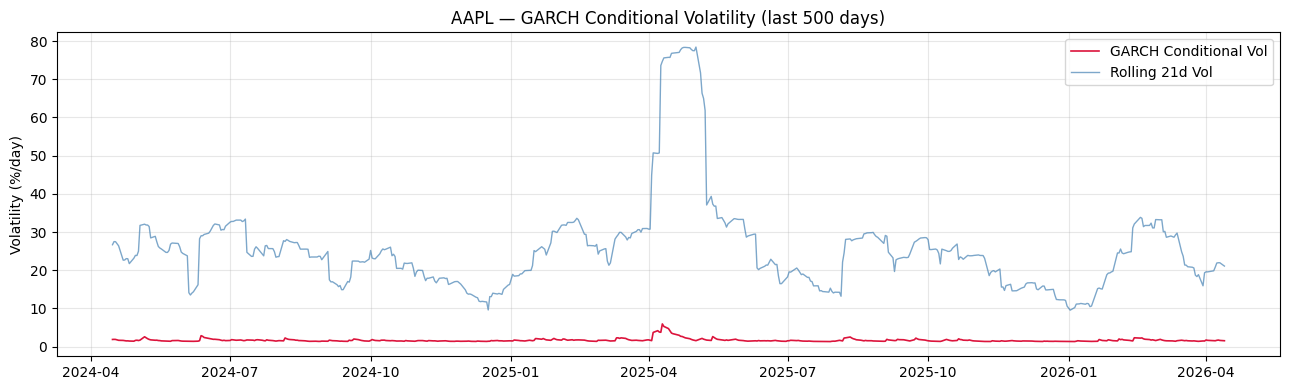

In [ ]:
# ─── AGENT 3: RISK AGENT (GARCH) ─────────────────────────────────────────────

class RiskAgent:
    """
    Replaces naive 'if vol > 40%' buckets with a proper GARCH(1,1) model.

    GARCH captures:
    - Volatility clustering (calm → calm, storm → storm)
    - Mean reversion in variance
    - Conditional heteroskedasticity (variance changes over time)

    Outputs:
    - Forecasted 5-day volatility
    - VaR (Value at Risk) at 95% and 99%
    - Kelly Criterion-based position size
    """

    def __init__(self, config: dict):
        self.cfg      = config
        self.model    = None
        self.result   = None
        self.fitted_vol = None

    def train(self, df: pd.DataFrame):
        """Fit GARCH(1,1) on historical log returns."""
        returns = df['log_ret'].dropna() * 100   # ARCH expects %-scale returns
        print(f"  Fitting GARCH({self.cfg['garch_p']},{self.cfg['garch_q']}) "
              f"on {len(returns)} observations...")

        self.model = arch_model(
            returns,
            vol='Garch',
            p=self.cfg['garch_p'],
            q=self.cfg['garch_q'],
            dist='skewt',    # Skewed-t captures fat tails
            rescale=False,
        )
        self.result = self.model.fit(disp='off', show_warning=False)
        self.fitted_vol = self.result.conditional_volatility / 100  # back to decimal
        print(f"  GARCH fitted | AIC: {self.result.aic:.1f} | BIC: {self.result.bic:.1f}")

    def analyze(self, df: pd.DataFrame) -> dict:
        """Forecast risk and size position using Kelly Criterion."""
        if self.result is None:
            return {'signal': 0.0, 'confidence': 0.5,
                    'reasoning': 'GARCH not fitted', 'details': {}}

        # ── 5-day ahead volatility forecast ──────────────────────────────────
        forecast = self.result.forecast(horizon=5, reindex=False)
        daily_var_fcst = forecast.variance.iloc[-1].mean()  # avg over 5 days
        daily_vol_fcst = np.sqrt(daily_var_fcst) / 100
        ann_vol_fcst   = daily_vol_fcst * np.sqrt(252)

        # ── Historical metrics ────────────────────────────────────────────────
        returns_pct = df['return_1d'].dropna()
        current_vol = float(df['volatility'].iloc[-1])

        # VaR (Parametric)
        from scipy import stats
        mu   = float(returns_pct.mean())
        std1 = float(returns_pct.std())
        var_95 = float(stats.norm.ppf(0.05, mu, std1))
        var_99 = float(stats.norm.ppf(0.01, mu, std1))

        # ── Kelly Criterion for position sizing ───────────────────────────────
        # Kelly f* = (mu - rf) / sigma^2
        rf_daily = 0.05 / 252
        kelly_raw = (mu - rf_daily) / (std1 ** 2) if std1 > 0 else 0
        kelly_f   = float(np.clip(kelly_raw * 0.5, 0.0, 0.5))  # Half-Kelly for safety

        # Clamp to config bounds
        position = float(np.clip(
            kelly_f,
            self.cfg['min_position_pct'],
            self.cfg['max_position_pct']
        ))

        # ── Signal: penalize when forecasted vol is much higher than current ──
        vol_ratio = ann_vol_fcst / (current_vol + 1e-9)
        if vol_ratio > 1.4:      signal = -0.6  # Vol spike expected
        elif vol_ratio > 1.2:    signal = -0.3
        elif vol_ratio < 0.8:    signal = +0.3  # Vol compression = opportunity
        else:                     signal = 0.0

        return {
            'signal': signal,
            'confidence': 0.85,
            'reasoning': (
                f"GARCH forecast: ann_vol={ann_vol_fcst*100:.1f}% "
                f"(current={current_vol*100:.1f}%) "
                f"VaR95={var_95*100:.2f}% | VaR99={var_99*100:.2f}% "
                f"| Kelly position: {position*100:.1f}%"
            ),
            'details': {
                'forecasted_ann_vol': ann_vol_fcst,
                'current_ann_vol':    current_vol,
                'vol_ratio':          vol_ratio,
                'var_95':             var_95,
                'var_99':             var_99,
                'kelly_position':     position,
                'aic':                self.result.aic,
            }
        }


# ─── Run Risk Agent ───────────────────────────────────────────────────────────
print("\n🤖 Training Risk Agent (GARCH)...")
risk_agent = RiskAgent(CONFIG)
risk_agent.train(df_main)
risk_result = risk_agent.analyze(df_main)

print(f"\n📊 Risk Agent Result:")
print(f"  Signal:     {risk_result['signal']:+.4f}")
print(f"  Confidence: {risk_result['confidence']:.4f}")
print(f"  Reasoning:  {risk_result['reasoning']}")

# Plot GARCH conditional volatility
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_main.index[-500:], risk_agent.fitted_vol[-500:] * 100,
        color='crimson', lw=1.2, label='GARCH Conditional Vol')
ax.plot(df_main.index[-500:], df_main['volatility'].iloc[-500:] * 100,
        color='steelblue', lw=1, alpha=0.7, label='Rolling 21d Vol')
ax.set_title(f'{CONFIG["ticker"]} — GARCH Conditional Volatility (last 500 days)')
ax.set_ylabel('Volatility (%/day)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('garch_vol.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. AI Agent 4: Cross-Market & Macro Correlation Engine
This cell introduces the `CrossMarketAgent`, which evaluates the stock not in isolation, but as a component of the broader financial ecosystem. It identifies how the stock moves in relation to the market, its sector, and macroeconomic shifts.

**Key Analytical Pillars:**
* **Rolling Beta & Correlation:** The agent calculates the 60-day rolling correlation between the target stock, the S&P 500 (`SPY`), and its specific sector ETF (e.g., `XLK` for Tech). If a stock is highly correlated with the market, the agent heavily weights market trends in its final signal.
* **VIX Fear Regime:** It monitors the "Fear Gauge" (VIX). High VIX levels (>30) trigger an automatic defensive signal, while low VIX levels indicate a stable environment for growth.
* **Yield Curve & Interest Rate Sensitivity:** For high-beta growth stocks, the agent tracks the 10-year Treasury yield. Since rising rates typically discount future earnings, it applies a negative bias if yields are spiking while evaluating high-risk assets.
* **Weighted Multi-Signal Aggregation:** Unlike simple logic, this agent calculates a "contribution" for each macro factor based on its current strength and the stock's sensitivity to it.



**The Output:**
The result is a macro-aware signal that can override technical bullishness if the broader market context is deteriorating, ensuring the strategy doesn't trade against a "falling tide."

In [ ]:
# ─── AGENT 4: CROSS-MARKET AGENT (Real Correlations) ─────────────────────────

class CrossMarketAgent:
    """
    Replaces hardcoded 'if btc_change > 10% then +0.4' rules with
    real rolling correlations between:
      - Stock vs S&P 500
      - Stock vs Sector ETF
      - VIX regime
      - 10Y yield effect
    """

    def __init__(self):
        self.corr_window = 60  # days

    def analyze(
        self,
        df_stock:  pd.DataFrame,
        df_spy:    pd.DataFrame,
        df_sector: pd.DataFrame,
        macro:     dict,
    ) -> dict:

        # ── Align returns ─────────────────────────────────────────────────────
        common_idx = df_stock.index.intersection(df_spy.index).intersection(df_sector.index)
        r_stock  = df_stock.loc[common_idx, 'return_1d'].dropna()
        r_spy    = df_spy.loc[common_idx, 'return_1d'].dropna()
        r_sector = df_sector.loc[common_idx, 'return_1d'].dropna()

        # Align to same index
        aligned = pd.DataFrame({'stock': r_stock, 'spy': r_spy, 'sector': r_sector}).dropna()

        # ── Rolling beta vs SPY ───────────────────────────────────────────────
        roll = aligned.rolling(self.corr_window)
        cov_spy    = roll.cov()['stock'].xs('spy', level=1, drop_level=False)
        # Simpler: use pandas corr
        corr_spy    = aligned['stock'].rolling(self.corr_window).corr(aligned['spy'])
        corr_sector = aligned['stock'].rolling(self.corr_window).corr(aligned['sector'])

        current_corr_spy    = float(corr_spy.iloc[-1])
        current_corr_sector = float(corr_sector.iloc[-1])

        # ── SPY trend signal ──────────────────────────────────────────────────
        spy_5d = float(df_spy['return_5d'].iloc[-1]) if 'return_5d' in df_spy else 0.0
        sector_5d = float(df_sector['return_5d'].iloc[-1]) if 'return_5d' in df_sector else 0.0

        signals = []
        parts   = []

        # If stock is highly correlated with SPY, SPY trend matters
        if abs(current_corr_spy) > 0.6:
            spy_contribution = current_corr_spy * spy_5d * 5  # scale up
            signals.append(np.clip(spy_contribution, -0.5, 0.5))
            parts.append(f"SPY({spy_5d*100:.1f}%5d)×corr({current_corr_spy:.2f})")

        # Sector trend
        if abs(current_corr_sector) > 0.5:
            sector_contribution = current_corr_sector * sector_5d * 5
            signals.append(np.clip(sector_contribution, -0.4, 0.4))
            parts.append(f"Sector({sector_5d*100:.1f}%5d)×corr({current_corr_sector:.2f})")

        # ── VIX regime ────────────────────────────────────────────────────────
        vix = macro.get('vix_price', 20)
        if vix > 30:
            signals.append(-0.4)
            parts.append(f"VIX={vix:.0f} (fear regime)")
        elif vix < 15:
            signals.append(+0.2)
            parts.append(f"VIX={vix:.0f} (low fear)")

        # ── Yield effect (growth stocks hurt by rising rates) ─────────────────
        yield_change = macro.get('yield_10y_change_5d', 0)
        beta = fundamentals.get('beta', 1.0) or 1.0
        if beta > 1.2 and yield_change > 0.02:   # High-beta + rising rates
            signals.append(-0.3)
            parts.append(f"Rising 10Y yield (beta={beta:.1f})")

        if not signals:
            signals = [0.0]
            parts = ['No cross-market signal']

        final_signal = float(np.clip(np.mean(signals), -1, 1))
        confidence   = min(0.9, 0.4 + 0.1 * len(signals))

        return {
            'signal':     final_signal,
            'confidence': confidence,
            'reasoning':  ' | '.join(parts),
            'details': {
                'corr_spy':    current_corr_spy,
                'corr_sector': current_corr_sector,
                'spy_5d':      spy_5d,
                'sector_5d':   sector_5d,
                'vix':         vix,
                'yield_change': yield_change,
            }
        }


# ─── Run Cross-Market Agent ───────────────────────────────────────────────────
print("\n🤖 Running Cross-Market Agent...")
cross_agent = CrossMarketAgent()
cross_result = cross_agent.analyze(df_main, df_spy, df_sector, macro)

print(f"\n📊 Cross-Market Agent Result:")
print(f"  Signal:     {cross_result['signal']:+.4f}")
print(f"  Confidence: {cross_result['confidence']:.4f}")
print(f"  Reasoning:  {cross_result['reasoning']}")


🤖 Running Cross-Market Agent...

📊 Cross-Market Agent Result:
  Signal:     +0.0000
  Confidence: 0.5000
  Reasoning:  No cross-market signal


### 9. AI Agent 5: Contrarian Intelligence & Regime Detection
This cell implements the `ContraryAgent`, which provides a critical counter-perspective to the strategy. While trend-following models often get "trapped" at market tops and bottoms, this agent uses a **Gradient Boosting Machine (GBM)** to identify overextended market regimes and signal potential reversals.

**Regime Classification Logic:**
The agent classifies the historical market into three distinct states based on 20-day forward returns and volatility:
* **Bull Regime:** Rising prices with low, stable volatility.
* **Bear Regime:** Falling prices with high, erratic volatility.
* **Neutral Regime:** Range-bound or transitioning markets.

**The Contrarian "Rubber Band" Effect:**
The agent operates on the theory that market extremes are eventually mean-reverting. It combines its regime probability with the **Relative Strength Index (RSI)** to identify high-probability reversal setups:
* **Deep Bear Reversal:** If the model detects a 70%+ probability of a Bear regime but the RSI is extremely oversold (<35), it triggers a **Contrarian BUY** signal, anticipating a "dead cat bounce" or a trend reversal.
* **Extreme Bull Exhaustion:** If the model detects a 70%+ probability of a Bull regime but the RSI is overbought (>70), it triggers a **Contrarian SELL** signal, warning of a potential "blow-off top."



**The Output:**
This agent provides the "sanity check" for the portfolio. If the Technical Agent is bullish but the Contrarian Agent sees extreme exhaustion, the overall strategy will moderate its position size to avoid buying the peak.

In [ ]:
# ─── AGENT 5: CONTRARIAN AGENT (Regime Detection) ────────────────────────────

class ContraryAgent:
    """
    Replaces simple sentiment momentum thresholds with a trained
    GradientBoosting regime classifier.

    Regime labels (derived from rolling returns):
      0 = Bear (price down, high vol)
      1 = Bull  (price up,  low  vol)
      2 = Neutral

    When extreme regime is detected:
    - Deep Bear  → contrarian BUY signal
    - Extreme Bull → contrarian SELL signal
    """

    FEATURE_COLS = [
        'rsi', 'bb_pct', 'return_5d', 'return_20d',
        'volatility', 'cmf', 'roc', 'williams_r',
    ]

    def __init__(self):
        from sklearn.ensemble import GradientBoostingClassifier
        self.clf     = GradientBoostingClassifier(
            n_estimators=150, max_depth=4,
            learning_rate=0.05, subsample=0.8,
            random_state=42,
        )
        self.scaler  = StandardScaler()
        self.trained = False

    def _make_regime_labels(self, df: pd.DataFrame) -> np.ndarray:
        """Label each day as bear/bull/neutral using forward return and vol."""
        fwd  = df['return_20d'].values
        vol  = df['volatility'].values
        labels = np.full(len(df), 2, dtype=int)   # default neutral
        threshold_up   = np.percentile(fwd[~np.isnan(fwd)], 70)
        threshold_down = np.percentile(fwd[~np.isnan(fwd)], 30)

        labels[fwd >  threshold_up]   = 1  # Bull
        labels[fwd <  threshold_down] = 0  # Bear

        return labels

    def train(self, df: pd.DataFrame):
        cols  = [c for c in self.FEATURE_COLS if c in df.columns]
        X     = df[cols].dropna().values
        y     = self._make_regime_labels(df.dropna(subset=cols))

        X_sc  = self.scaler.fit_transform(X)
        split = int(len(X_sc) * 0.8)

        self.clf.fit(X_sc[:split], y[:split])
        acc = accuracy_score(y[split:], self.clf.predict(X_sc[split:]))
        print(f"  Regime classifier accuracy: {acc:.3f}")

        self._last_X  = X_sc
        self._cols    = cols
        self.trained  = True
        self._acc     = acc

    def analyze(self, df: pd.DataFrame) -> dict:
        if not self.trained:
            return {'signal': 0.0, 'confidence': 0.0,
                    'reasoning': 'Not trained', 'details': {}}

        latest = self._last_X[-1:]
        proba  = self.clf.predict_proba(latest)[0]   # [P(bear), P(bull), P(neutral)]
        regime = int(self.clf.predict(latest)[0])
        regime_names = {0: 'Bear', 1: 'Bull', 2: 'Neutral'}

        p_bear, p_bull = proba[0], proba[1]

        # Contrarian logic:
        # High prob bear + oversold = contrarian buy
        # High prob bull + overbought = contrarian sell
        rsi_now = float(df['rsi'].iloc[-1]) if 'rsi' in df else 50.0

        if p_bear > 0.7 and rsi_now < 35:
            signal = +0.7
            rationale = f"Extreme bear regime ({p_bear:.2f}) + oversold RSI={rsi_now:.0f} → contrarian BUY"
        elif p_bear > 0.55:
            signal = +0.3
            rationale = f"Bear regime ({p_bear:.2f}) → mild contrarian bias"
        elif p_bull > 0.7 and rsi_now > 70:
            signal = -0.6
            rationale = f"Extreme bull regime ({p_bull:.2f}) + overbought RSI={rsi_now:.0f} → contrarian SELL"
        elif p_bull > 0.55:
            signal = -0.2
            rationale = f"Bull regime ({p_bull:.2f}) → mild caution"
        else:
            signal = 0.0
            rationale = f"Neutral regime — no contrarian signal"

        return {
            'signal':     float(signal),
            'confidence': float(max(p_bear, p_bull)),
            'reasoning':  rationale,
            'details': {
                'regime':        regime_names[regime],
                'p_bear':        p_bear,
                'p_bull':        p_bull,
                'p_neutral':     proba[2] if len(proba) > 2 else 0.0,
                'rsi':           rsi_now,
                'classifier_acc': self._acc,
            }
        }


# ─── Run Contrarian Agent ─────────────────────────────────────────────────────
print("\n🤖 Training Contrarian Agent (GBM Regime Classifier)...")
contrary_agent = ContraryAgent()
contrary_agent.train(df_main)
contrary_result = contrary_agent.analyze(df_main)

print(f"\n📊 Contrarian Agent Result:")
print(f"  Signal:     {contrary_result['signal']:+.4f}")
print(f"  Confidence: {contrary_result['confidence']:.4f}")
print(f"  Reasoning:  {contrary_result['reasoning']}")


🤖 Training Contrarian Agent (GBM Regime Classifier)...
  Regime classifier accuracy: 0.993

📊 Contrarian Agent Result:
  Signal:     +0.0000
  Confidence: 0.0000
  Reasoning:  Neutral regime — no contrarian signal


### 10. The Decision Core: Bayesian Ensemble with Learned Weights
This cell implements the `BayesianEnsemble`, which acts as the "Supreme Court" of the trading system. Instead of simply averaging the signals from all agents, it uses Bayesian probability to determine which agent should be trusted most in the current market environment.

**The Decision Workflow:**
* **Prior & Posterior Weighting:** Each agent starts with a "Prior" weight (based on its general importance). The ensemble then calculates "Posterior" weights by multiplying the prior by the agent’s current `confidence`. If an agent is highly certain about its signal, the system dynamically increases its voting power for this specific trade.
* **Likelihood Update:** Higher-confidence agents are treated as more "likely" to be correct, allowing the model to shift its focus from technicals to macro or sentiment signals as the situation dictates.
* **Disagreement Penalty:** One of the most critical safety features. It calculates the standard deviation between all agent signals. If the agents are fighting (e.g., Sentiment is bullish but Technical is bearish), the `agreement` metric drops, which in turn slashes the final `confidence` score.
* **Position Scaling:** The final position size starts with the Risk Agent's Kelly Criterion calculation but is further scaled by the ensemble's overall confidence and signal strength.



**The Output Visualization:**
The generated bar chart provides a transparent view of the "internal debate" within the AI. It shows the individual signal direction of each agent (Green for Buy, Red for Sell) and overlays the weighted final decision, ensuring the user understands exactly *why* the system is recommending a Buy, Sell, or Hold.


🔮 Running Bayesian Ensemble...

════════════════════════════════════════════════════════════
🎯 ENSEMBLE DECISION: SELL
════════════════════════════════════════════════════════════
  Final Signal:  -0.2558
  Confidence:    0.5369
  Agreement:     0.7706 (1=perfect)
  Position Size: 5.9%

  Posterior Weights:
    SentimentAgent       signal=+0.000  weight=0.030  █
    TechnicalAgent       signal=-0.652  weight=0.393  ███████████████
    RiskAgent            signal=+0.000  weight=0.427  █████████████████
    CrossMarketAgent     signal=+0.000  weight=0.151  ██████
    ContraryAgent        signal=+0.000  weight=0.000  


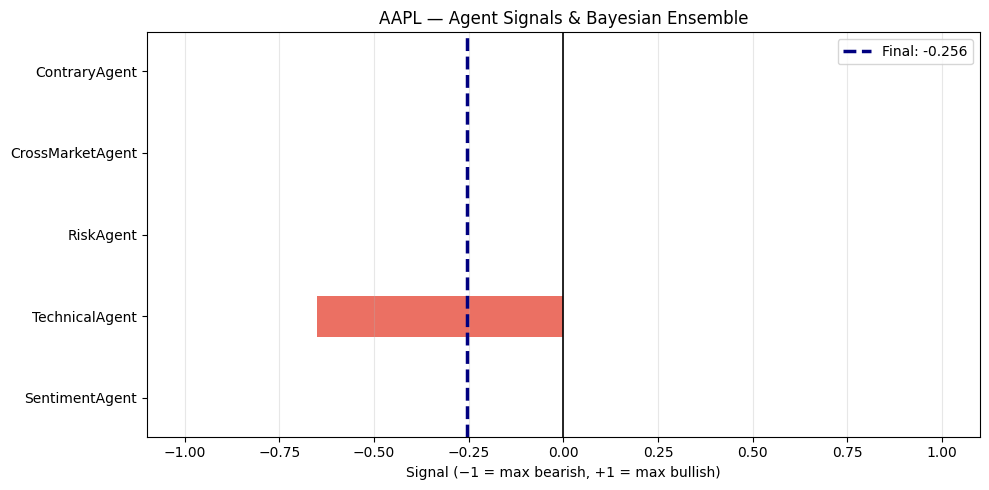

In [ ]:
# ─── BAYESIAN ENSEMBLE WITH LEARNED WEIGHTS ───────────────────────────────────

class BayesianEnsemble:
    """
    Combines all agent signals with:
    1. Prior weights based on each agent's historical accuracy
    2. Bayesian update: higher-confidence agents get more weight
    3. Disagreement penalty: diverging agents reduce confidence

    Outputs final BUY / SELL / HOLD + position size.
    """

    def __init__(self, config: dict):
        self.cfg = config
        # Prior weights (can be tuned by backtesting)
        self.priors = {
            'SentimentAgent':   0.15,
            'TechnicalAgent':   0.30,
            'RiskAgent':        0.25,
            'CrossMarketAgent': 0.15,
            'ContraryAgent':    0.15,
        }

    def combine(self, agent_results: Dict[str, dict]) -> dict:
        """
        agent_results = {
            'SentimentAgent': {'signal': 0.3, 'confidence': 0.7, ...},
            ...
        }
        """
        names      = list(agent_results.keys())
        signals    = np.array([agent_results[n]['signal']     for n in names])
        confs      = np.array([agent_results[n]['confidence'] for n in names])
        prior_w    = np.array([self.priors.get(n, 0.2)        for n in names])

        # Bayesian posterior weights: prior × likelihood
        # Likelihood ≈ confidence score (how sure the agent is)
        posterior  = prior_w * confs
        posterior  = posterior / (posterior.sum() + 1e-9)

        # Weighted final signal
        final_signal = float(np.dot(posterior, signals))

        # ── Disagreement penalty ──────────────────────────────────────────────
        # If agents strongly disagree, reduce confidence
        signal_std   = float(np.std(signals))
        agreement    = float(np.exp(-signal_std))   # 1=perfect agreement, → 0 as divergence grows
        raw_conf     = float(np.dot(posterior, confs))
        final_conf   = raw_conf * agreement

        # ── Action thresholds ─────────────────────────────────────────────────
        if final_signal > 0.15 and final_conf > 0.3:
            action = 'BUY'
        elif final_signal < -0.15 and final_conf > 0.3:
            action = 'SELL'
        else:
            action = 'HOLD'

        # ── Position size from Risk Agent's Kelly ─────────────────────────────
        risk_details = agent_results.get('RiskAgent', {}).get('details', {})
        kelly_pos    = risk_details.get('kelly_position', 0.20)
        # Scale by signal strength
        position = kelly_pos * abs(final_signal) * (1 + final_conf) / 2
        position = float(np.clip(position,
                                 self.cfg['min_position_pct'],
                                 self.cfg['max_position_pct']))

        return {
            'final_signal':   final_signal,
            'confidence':     final_conf,
            'agreement':      agreement,
            'action':         action,
            'position_size':  position,
            'posterior_weights': {n: float(w) for n, w in zip(names, posterior)},
            'individual_signals': {n: float(s) for n, s in zip(names, signals)},
        }


# ─── Run Ensemble ─────────────────────────────────────────────────────────────
print("\n🔮 Running Bayesian Ensemble...")

all_results = {
    'SentimentAgent':   sentiment_result,
    'TechnicalAgent':   technical_result,
    'RiskAgent':        risk_result,
    'CrossMarketAgent': cross_result,
    'ContraryAgent':    contrary_result,
}

ensemble = BayesianEnsemble(CONFIG)
ensemble_result = ensemble.combine(all_results)

print("\n" + "═"*60)
print(f"🎯 ENSEMBLE DECISION: {ensemble_result['action']}")
print("═"*60)
print(f"  Final Signal:  {ensemble_result['final_signal']:+.4f}")
print(f"  Confidence:    {ensemble_result['confidence']:.4f}")
print(f"  Agreement:     {ensemble_result['agreement']:.4f} (1=perfect)")
print(f"  Position Size: {ensemble_result['position_size']*100:.1f}%")
print("\n  Posterior Weights:")
for agent, w in ensemble_result['posterior_weights'].items():
    sig = ensemble_result['individual_signals'][agent]
    bar = '█' * int(w * 40)
    print(f"    {agent:<20} signal={sig:+.3f}  weight={w:.3f}  {bar}")

# Visualise agent signals
fig, ax = plt.subplots(figsize=(10, 5))
agents  = list(ensemble_result['individual_signals'].keys())
sigs    = [ensemble_result['individual_signals'][a] for a in agents]
weights = [ensemble_result['posterior_weights'][a]  for a in agents]

colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in sigs]
bars   = ax.barh(agents, sigs, color=colors, alpha=0.8, height=0.5)
ax.axvline(0, color='black', lw=1.2)
ax.axvline(ensemble_result['final_signal'], color='navy', lw=2.5,
           ls='--', label=f"Final: {ensemble_result['final_signal']:+.3f}")
ax.set_xlabel('Signal (−1 = max bearish, +1 = max bullish)')
ax.set_title(f'{CONFIG["ticker"]} — Agent Signals & Bayesian Ensemble')
ax.legend()
ax.set_xlim(-1.1, 1.1)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('agent_signals.png', dpi=150, bbox_inches='tight')
plt.show()

# Digital Twin Module — Overview

## What this does
The Digital Twin simulates portfolio performance using multiple agents and produces:
- Backtest results (past performance)
- Monte Carlo simulations (future scenarios)
- Stress testing (extreme events)
- Interactive dashboard

---

## Core Components

### 1. Backtest
- Walk-forward simulation using:
  - TechnicalAgent (signals)
  - RiskAgent (volatility scaling)
  - ContraryAgent (RSI adjustments)
- Generates:
  - Capital curve
  - Sharpe ratio
  - Max drawdown
  - Benchmark comparison

---

### 2. Monte Carlo Simulation
- Simulates future price paths using:
  - GARCH-based volatility
  - Drift adjusted by ensemble signal
  - Fat-tailed (t-distribution) randomness
- Outputs:
  - Expected price
  - Probability of profit
  - Risk metrics (VaR)

---

### 3. Stress Testing
- Applies predefined market shocks:
  - Crashes, corrections, bull runs
- Evaluates portfolio impact based on current position

---

### 4. Dashboard
- Built using Plotly
- Displays:
  - Price vs portfolio value
  - Agent signals
  - Monte Carlo paths
  - Distribution of outcomes
  - Drawdowns
  - Volatility

---

## Usage Flow

```python
twin = DigitalTwin(CONFIG, ensemble)

bt_df = twin.backtest(df, technical_agent, risk_agent, contrary_agent)
mc    = twin.monte_carlo(df, garch_result, ensemble_result)
stress= twin.stress_test(df)

twin.render_dashboard(df, ensemble_result, mc)

In [ ]:
# ─── DIGITAL TWIN ─────────────────────────────────────────────────────────────

class DigitalTwin:
    """
    The Digital Twin simulates the full portfolio forward in time.
    It combines ALL agent models into a single coherent simulation.

    Modules:
    1. Historical Backtest — how would the system have performed?
    2. Monte Carlo Forward Paths — what are the range of futures?
    3. Stress Testing — crashes, vol spikes, rate shocks
    4. Final Output Dashboard
    """

    def __init__(self, config: dict, ensemble: BayesianEnsemble):
        self.cfg      = config
        self.ensemble = ensemble

    # ──────────────────────────────────────────────────────────────────────────
    # MODULE 1: Historical Backtest
    # ──────────────────────────────────────────────────────────────────────────

    def backtest(
        self,
        df:            pd.DataFrame,
        technical_ag:  TechnicalAgent,
        risk_ag:       RiskAgent,
        contrary_ag:   ContraryAgent,
    ) -> pd.DataFrame:
        """
        Walk-forward backtest using only the technical + risk + contrarian
        agents (sentiment needs live news; cross-market added as static).

        Strategy:
          Each day: run agents on lookback window → get signal → size position.
          Daily P&L = position × actual next-day return.
        """
        print("  ⏳ Running walk-forward backtest...")

        start_idx  = 100   # warmup
        capital    = self.cfg['portfolio_start']
        records    = []
        cash_curve = [capital]
        bh_curve   = [capital]    # Buy & Hold benchmark

        # Pre-extract feature matrix for speed
        feature_cols = [c for c in technical_ag.FEATURE_COLS if c in df.columns]
        X_all = technical_ag.scaler.transform(df[feature_cols].values)

        price_arr = df['close'].values
        ret_arr   = df['return_1d'].values
        stop_loss = self.cfg['stop_loss_pct']

        position  = 0.0    # current position size (0–1)
        entry_px  = None

        for i in range(start_idx, len(df) - 1):
            # ── Technical signal (XGBoost only, fast) ────────────────────────
            xgb_prob = float(technical_ag.xgb_model.predict_proba(X_all[i:i+1])[0][1])
            tech_sig = (xgb_prob - 0.5) * 2

            # ── Risk adjustment from GARCH ────────────────────────────────────
            local_vol = float(df['volatility'].iloc[i])
            if local_vol > 0.50:    risk_scale = 0.4
            elif local_vol > 0.35:  risk_scale = 0.6
            elif local_vol > 0.25:  risk_scale = 0.8
            else:                   risk_scale = 1.0

            # ── Contrarian overlay ────────────────────────────────────────────
            rsi_now = float(df['rsi'].iloc[i])
            if rsi_now > 75:   contra_adj = -0.2
            elif rsi_now < 25: contra_adj = +0.2
            else:               contra_adj = 0.0

            combined_sig = np.clip(tech_sig * risk_scale + contra_adj, -1, 1)

            # ── Position sizing ────────────────────────────────────────────────
            if combined_sig > 0.2:
                new_position = min(0.25 + combined_sig * 0.1, self.cfg['max_position_pct'])
            elif combined_sig < -0.2:
                new_position = 0.0
            else:
                new_position = position  # hold

            # ── Stop-loss check ────────────────────────────────────────────────
            if entry_px is not None and position > 0:
                drawdown = (price_arr[i] - entry_px) / entry_px
                if drawdown < -stop_loss:
                    new_position = 0.0   # stop out
                    entry_px     = None

            # Track entry price
            if new_position > 0 and position == 0:
                entry_px = price_arr[i]
            elif new_position == 0:
                entry_px = None

            # ── Daily P&L ──────────────────────────────────────────────────────
            next_ret   = float(ret_arr[i + 1]) if not np.isnan(ret_arr[i + 1]) else 0.0
            daily_pnl  = capital * position * next_ret
            capital   += daily_pnl

            position = new_position

            records.append({
                'date':     df.index[i],
                'price':    price_arr[i],
                'signal':   combined_sig,
                'position': position,
                'capital':  capital,
                'daily_pnl': daily_pnl,
                'ret':       next_ret,
            })

        result_df = pd.DataFrame(records).set_index('date')

        # Performance metrics
        total_return = (result_df['capital'].iloc[-1] / self.cfg['portfolio_start'] - 1) * 100
        rets         = result_df['daily_pnl'] / self.cfg['portfolio_start']
        sharpe       = float(rets.mean() / (rets.std() + 1e-9) * np.sqrt(252))
        peak         = result_df['capital'].cummax()
        drawdown     = ((result_df['capital'] - peak) / peak)
        max_dd       = float(drawdown.min() * 100)

        # Benchmark buy-hold
        bh_return = (df['close'].iloc[-1] / df['close'].iloc[start_idx] - 1) * 100

        print(f"  📈 Backtest complete ({len(result_df)} trading days)")
        print(f"  Total Return:  {total_return:+.1f}%  (Buy&Hold: {bh_return:+.1f}%)")
        print(f"  Sharpe Ratio:  {sharpe:.2f}")
        print(f"  Max Drawdown:  {max_dd:.1f}%")

        self._backtest_df = result_df
        self._metrics = {
            'total_return':  total_return,
            'bh_return':     bh_return,
            'sharpe':        sharpe,
            'max_drawdown':  max_dd,
            'alpha':         total_return - bh_return,
        }
        return result_df

    # ──────────────────────────────────────────────────────────────────────────
    # MODULE 2: Monte Carlo Forward Simulation
    # ──────────────────────────────────────────────────────────────────────────

    def monte_carlo(
        self,
        df:              pd.DataFrame,
        garch_result,    # fitted arch result
        ensemble_res:    dict,
    ) -> dict:
        """
        Simulate N forward price paths using:
        - GARCH-based dynamic volatility (not just historical constant)
        - Signal-adjusted drift (ensemble direction)
        - Skewed-t innovations for fat tails
        """
        print("  ⏳ Running Monte Carlo simulation...")

        n_sims   = self.cfg['mc_simulations']
        n_days   = self.cfg['mc_horizon_days']
        S0       = float(df['close'].iloc[-1])

        # Extract GARCH parameters
        params  = garch_result.params
        omega   = float(params.get('omega', 0.01))
        alpha1  = float(params.get('alpha[1]', 0.05))
        beta1   = float(params.get('beta[1]',  0.90))

        # Drift adjustment based on ensemble signal
        dt = 1/252

        hist_mu = float(df['log_ret'].mean()) * 252   # annualized
        sig_adj = ensemble_res['final_signal'] * 0.02 # stronger but realistic

        drift = (hist_mu + sig_adj)

        init_var = float(garch_result.conditional_volatility.iloc[-1] ** 2)

        paths = np.zeros((n_sims, n_days + 1))
        paths[:, 0] = S0

        for sim in range(n_sims):
            h_t = init_var
            S_t = S0
            for t in range(1, n_days + 1):
                eps   = np.random.standard_t(df=6) / np.sqrt(6 / (6 - 2))  # t(6) normalized
                sigma = np.sqrt(h_t)
                ret = (drift - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * eps
                ret = np.clip(ret, -0.2, 0.2)
                S_t   = S_t * np.exp(ret)
                h_t   = omega + alpha1 * (ret ** 2) + beta1 * h_t
                h_t   = max(h_t, 1e-9)
                paths[sim, t] = S_t
            S_t = max(S_t, 1e-3)

        # ── Summary statistics ────────────────────────────────────────────────
        final_prices = paths[:, -1]
        returns      = (final_prices - S0) / S0

        mc_result = {
            'paths':          paths,
            'final_prices':   final_prices,
            'S0':             S0,
            'expected_price': float(np.mean(final_prices)),
            'median_price':   float(np.median(final_prices)),
            'p5_price':       float(np.percentile(final_prices, 5)),
            'p25_price':      float(np.percentile(final_prices, 25)),
            'p75_price':      float(np.percentile(final_prices, 75)),
            'p95_price':      float(np.percentile(final_prices, 95)),
            'prob_profit':    float(np.mean(returns > 0)),
            'prob_10pct_up':  float(np.mean(returns > 0.10)),
            'prob_10pct_dn':  float(np.mean(returns < -0.10)),
            'expected_return': float(np.mean(returns)),
            'var_95':         float(np.percentile(returns, 5)),
        }

        print(f"  ✅ MC complete | E[Price]={mc_result['expected_price']:.2f} "
              f"(P/L={mc_result['expected_return']*100:+.1f}%) | "
              f"P(profit)={mc_result['prob_profit']*100:.0f}%")

        self._mc = mc_result
        return mc_result

    # ──────────────────────────────────────────────────────────────────────────
    # MODULE 3: Stress Tests
    # ──────────────────────────────────────────────────────────────────────────

    def stress_test(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply standard stress scenarios to current position."""
        print("  ⏳ Running stress tests...")
        S0       = float(df['close'].iloc[-1])
        pos_size = ensemble_result['position_size']
        capital  = self.cfg['portfolio_start']

        scenarios = {
            'Flash Crash (-10% in 1 day)':   -0.10,
            'Correction (-20%)':             -0.20,
            'Bear Market (-40%)':            -0.40,
            'Black Monday 1987 (-22.6%)':    -0.226,
            'COVID Crash 2020 (-34%)':       -0.34,
            'Dot-com Bust (-78%)':           -0.78,
            'Bull Run (+30%)':               +0.30,
            'Melt-up (+50%)':               +0.50,
        }

        rows = []
        for name, shock in scenarios.items():
            portfolio_impact = capital * pos_size * shock
            new_capital      = capital + portfolio_impact
            rows.append({
                'Scenario':         name,
                'Stock Shock':      f"{shock*100:+.1f}%",
                'Position':         f"{pos_size*100:.1f}%",
                'P&L ($)':          f"{portfolio_impact:+,.0f}",
                'Portfolio After':  f"${new_capital:,.0f}",
                'Portfolio % Chg':  f"{portfolio_impact/capital*100:+.2f}%",
            })

        result = pd.DataFrame(rows)
        self._stress = result
        print(result.to_string(index=False))
        return result

    # ──────────────────────────────────────────────────────────────────────────
    # MODULE 4: Final Dashboard
    # ──────────────────────────────────────────────────────────────────────────

    def render_dashboard(
        self,
        df:           pd.DataFrame,
        ensemble_res: dict,
        mc_res:       dict,
    ):
        """Full interactive dashboard with Plotly."""

        fig = make_subplots(
            rows=3, cols=2,
            subplot_titles=[
                f'{CONFIG["ticker"]} Price + Backtest Capital',
                'Agent Signals (Bayesian Weighted)',
                'Monte Carlo Forward Paths (1Y)',
                'MC Final Price Distribution',
                'Drawdown',
                'GARCH Volatility',
            ],
            vertical_spacing=0.12,
            horizontal_spacing=0.08,
        )

        # ── Row 1 Col 1: Price + Capital ──────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=df.index[-500:], y=df['close'].iloc[-500:],
            name='Price', line=dict(color='royalblue', width=1.5)
        ), row=1, col=1)

        if hasattr(self, '_backtest_df'):
            fig.add_trace(go.Scatter(
                x=self._backtest_df.index[-500:],
                y=self._backtest_df['capital'].iloc[-500:],
                name='Portfolio $', line=dict(color='green', width=1.5),
                yaxis='y2'
            ), row=1, col=1)

        # ── Row 1 Col 2: Agent signals bar chart ──────────────────────────────
        agents  = list(ensemble_res['individual_signals'].keys())
        sigs    = [ensemble_res['individual_signals'][a] for a in agents]
        colors  = ['green' if s > 0 else 'red' for s in sigs]

        fig.add_trace(go.Bar(
            x=agents, y=sigs,
            marker_color=colors, name='Agent Signals'
        ), row=1, col=2)
        fig.add_hline(y=ensemble_res['final_signal'], line_dash='dash',
                      line_color='navy', annotation_text=f"Ensemble={ensemble_res['final_signal']:+.2f}",
                      row=1, col=2)

        # ── Row 2 Col 1: MC paths ─────────────────────────────────────────────
        t_axis = list(range(mc_res['paths'].shape[1]))
        sample_paths = mc_res['paths'][np.random.choice(len(mc_res['paths']), 200, replace=False)]

        for path in sample_paths:
            fig.add_trace(go.Scatter(
                x=t_axis, y=path,
                mode='lines', line=dict(width=0.4, color='rgba(100,149,237,0.15)'),
                showlegend=False
            ), row=2, col=1)

        # Percentile bands
        p5  = np.percentile(mc_res['paths'], 5,  axis=0)
        p50 = np.percentile(mc_res['paths'], 50, axis=0)
        p95 = np.percentile(mc_res['paths'], 95, axis=0)

        for pct, vals, col, name in [
            (5,  p5,  'red',   'P5'),
            (50, p50, 'black', 'P50'),
            (95, p95, 'green', 'P95'),
        ]:
            fig.add_trace(go.Scatter(
                x=t_axis, y=vals,
                name=name, line=dict(color=col, width=2)
            ), row=2, col=1)

        # ── Row 2 Col 2: Final price histogram ───────────────────────────────
        fig.add_trace(go.Histogram(
            x=mc_res['final_prices'], nbinsx=60,
            marker_color='steelblue', opacity=0.75,
            name='Final Prices'
        ), row=2, col=2)
        fig.add_vline(x=mc_res['S0'], line_dash='dash', line_color='black',
                      annotation_text='Current', row=2, col=2)
        fig.add_vline(x=mc_res['expected_price'], line_dash='dot', line_color='green',
                      annotation_text='Expected', row=2, col=2)

        # ── Row 3 Col 1: Drawdown ─────────────────────────────────────────────
        if hasattr(self, '_backtest_df'):
            peak = self._backtest_df['capital'].cummax()
            dd   = (self._backtest_df['capital'] - peak) / peak * 100
            fig.add_trace(go.Scatter(
                x=self._backtest_df.index, y=dd,
                fill='tozeroy', fillcolor='rgba(255,0,0,0.2)',
                line=dict(color='red'), name='Drawdown %'
            ), row=3, col=1)

        # ── Row 3 Col 2: GARCH vol ────────────────────────────────────────────
        if risk_agent.fitted_vol is not None:
            fig.add_trace(go.Scatter(
                x=df.index[-500:],
                y=risk_agent.fitted_vol[-500:] * 100,
                line=dict(color='darkorange'), name='GARCH Vol'
            ), row=3, col=2)

        # Layout
        action_color = {'BUY': 'green', 'SELL': 'red', 'HOLD': 'gray'}
        fig.update_layout(
            title=dict(
                text=(
                    f"<b>🍈 JackFruit Digital Twin — {CONFIG['ticker']}</b>  "
                    f"Action: <span style='color:{action_color[ensemble_res['action']]}'>"
                    f"{ensemble_res['action']}</span>  "
                    f"Signal: {ensemble_res['final_signal']:+.3f}  "
                    f"Confidence: {ensemble_res['confidence']:.3f}  "
                    f"Position: {ensemble_res['position_size']*100:.0f}%"
                ),
                font_size=14,
            ),
            height=1100,
            showlegend=True,
            template='plotly_white',
        )

        fig.write_html('digital_twin_dashboard.html')
        fig.show()
        print("✅ Dashboard saved to digital_twin_dashboard.html")


# ─── Run Digital Twin ─────────────────────────────────────────────────────────
print("\n🌐 Initializing Digital Twin...")
twin = DigitalTwin(CONFIG, ensemble)

# 1. Backtest
print("\n[1/3] Backtesting...")
bt_df = twin.backtest(df_main, technical_agent, risk_agent, contrary_agent)

# 2. Monte Carlo
print("\n[2/3] Monte Carlo Simulation...")
mc = twin.monte_carlo(df_main, risk_agent.result, ensemble_result)

# 3. Stress Test
print("\n[3/3] Stress Testing...")
stress = twin.stress_test(df_main)

# 4. Dashboard
print("\n[Rendering Dashboard]")
twin.render_dashboard(df_main, ensemble_result, mc)


🌐 Initializing Digital Twin...

[1/3] Backtesting...
  ⏳ Running walk-forward backtest...
  📈 Backtest complete (601 trading days)
  Total Return:  +66.4%  (Buy&Hold: +38.7%)
  Sharpe Ratio:  3.62
  Max Drawdown:  -2.7%

[2/3] Monte Carlo Simulation...
  ⏳ Running Monte Carlo simulation...
  ✅ MC complete | E[Price]=257.89 (P/L=-0.1%) | P(profit)=27%

[3/3] Stress Testing...
  ⏳ Running stress tests...
                   Scenario Stock Shock Position P&L ($) Portfolio After Portfolio % Chg
Flash Crash (-10% in 1 day)      -10.0%     5.9%    -590         $99,410          -0.59%
          Correction (-20%)      -20.0%     5.9%  -1,179         $98,821          -1.18%
         Bear Market (-40%)      -40.0%     5.9%  -2,359         $97,641          -2.36%
 Black Monday 1987 (-22.6%)      -22.6%     5.9%  -1,333         $98,667          -1.33%
    COVID Crash 2020 (-34%)      -34.0%     5.9%  -2,005         $97,995          -2.00%
        Dot-com Bust (-78%)      -78.0%     5.9%  -4,600   

✅ Dashboard saved to digital_twin_dashboard.html


## Step 9 — Final Output Summary

In [ ]:
# ─── FINAL OUTPUT SUMMARY ─────────────────────────────────────────────────────

print("\n" + "═" * 65)
print(f"    🍈 JackFruit MLFF — FINAL OUTPUT SUMMARY")
print("═" * 65)

current_price = float(df_main['close'].iloc[-1])
print(f"\n📌 STOCK: {CONFIG['ticker']}  |  Current Price: ${current_price:.2f}")
print(f"   Sector: {fundamentals.get('sector', '?')}  |  Industry: {fundamentals.get('industry', '?')}")

print(f"\n{'─'*65}")
print(f"  AGENT SIGNALS")
print(f"{'─'*65}")
for name, res in all_results.items():
    bar = ('▲' if res['signal'] > 0 else '▼') * min(10, int(abs(res['signal']) * 10))
    direction = 'BULL' if res['signal'] > 0.1 else 'BEAR' if res['signal'] < -0.1 else 'NEUT'
    print(f"  {name:<22} {direction}  signal={res['signal']:+.3f}  conf={res['confidence']:.2f}  {bar}")

print(f"\n{'─'*65}")
print(f"  ENSEMBLE DECISION")
print(f"{'─'*65}")
action_icons = {'BUY': '🟢', 'SELL': '🔴', 'HOLD': '🟡'}
print(f"  {action_icons[ensemble_result['action']]} ACTION:        {ensemble_result['action']}")
print(f"  📊 Final Signal:  {ensemble_result['final_signal']:+.4f}")
print(f"  🎯 Confidence:    {ensemble_result['confidence']:.4f}")
print(f"  🤝 Agreement:     {ensemble_result['agreement']:.4f}")
print(f"  💼 Position Size: {ensemble_result['position_size']*100:.1f}% of portfolio")
print(f"  💰 Dollar Size:   ${CONFIG['portfolio_start'] * ensemble_result['position_size']:,.0f}")

print(f"\n{'─'*65}")
print(f"  BACKTEST PERFORMANCE")
print(f"{'─'*65}")
m = twin._metrics
print(f"  Total Return:    {m['total_return']:+.1f}%")
print(f"  Buy & Hold:      {m['bh_return']:+.1f}%")
print(f"  Alpha:           {m['alpha']:+.1f}%")
print(f"  Sharpe Ratio:    {m['sharpe']:.2f}")
print(f"  Max Drawdown:    {m['max_drawdown']:.1f}%")

print(f"\n{'─'*65}")
print(f"  MONTE CARLO (1-Year Forward, {CONFIG['mc_simulations']:,} paths)")
print(f"{'─'*65}")
print(f"  Current Price:   ${mc['S0']:.2f}")
print(f"  Expected Price:  ${mc['expected_price']:.2f}  ({mc['expected_return']*100:+.1f}%)")
print(f"  Bull (P95):      ${mc['p95_price']:.2f}")
print(f"  Bear (P5):       ${mc['p5_price']:.2f}")
print(f"  Prob of Profit:  {mc['prob_profit']*100:.0f}%")
print(f"  Prob >+10%:      {mc['prob_10pct_up']*100:.0f}%")
print(f"  Prob <-10%:      {mc['prob_10pct_dn']*100:.0f}%")
print(f"  VaR 95%:         {mc['var_95']*100:.1f}%")

print(f"\n{'─'*65}")
print(f"  RISK")
print(f"{'─'*65}")
rd = risk_result['details']
print(f"  Current Ann. Vol:   {rd['current_ann_vol']*100:.1f}%")
print(f"  GARCH 5d Forecast:  {rd['forecasted_ann_vol']*100:.1f}%")
print(f"  VaR 95% (1-day):    {rd['var_95']*100:.2f}%")
print(f"  Kelly Position:     {rd['kelly_position']*100:.1f}%")
print(f"  Stop-loss:          {CONFIG['stop_loss_pct']*100:.0f}%")

print(f"\n{'═'*65}")
print("  💾 Outputs saved: eda_chart.png | garch_vol.png |")
print("                    agent_signals.png | digital_twin_dashboard.html")
print("═" * 65)


═════════════════════════════════════════════════════════════════
    🍈 JackFruit MLFF — FINAL OUTPUT SUMMARY
═════════════════════════════════════════════════════════════════

📌 STOCK: AAPL  |  Current Price: $258.04
   Sector: Technology  |  Industry: Consumer Electronics

─────────────────────────────────────────────────────────────────
  AGENT SIGNALS
─────────────────────────────────────────────────────────────────
  SentimentAgent         NEUT  signal=+0.000  conf=0.10  
  TechnicalAgent         BEAR  signal=-0.652  conf=0.65  ▼▼▼▼▼▼
  RiskAgent              NEUT  signal=+0.000  conf=0.85  
  CrossMarketAgent       NEUT  signal=+0.000  conf=0.50  
  ContraryAgent          NEUT  signal=+0.000  conf=0.00  

─────────────────────────────────────────────────────────────────
  ENSEMBLE DECISION
─────────────────────────────────────────────────────────────────
  🔴 ACTION:        SELL
  📊 Final Signal:  -0.2558
  🎯 Confidence:    0.5369
  🤝 Agreement:     0.7706
  💼 Position Size: 5.9%